# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

In [1]:
# In this project, we will learn how to build and train regression models using Scikit-Learn library. Scikit-learn
# is a free machine learning library developed for python. Scikit-learn offers several algorithms for 
# classification, regression, and clustering. In this project, we will learn how to train XG-Boost algorithm,
# XGBoost is the go-to algorithm for most developers and has won several Kaggle competitions.
# Why does XGBoost work well?
    # Since the technique is an ensemble algorithm, it is very robust and could work well with several data types
    # and complex distributions.
    # XG-Boost has a many tunable hyperparameters that could improve model fitting.

# TASK #2: IMPORT KEY LIBRARIES & DATASETS

In [4]:
# In this task, we will import our key libraries and dataset.

In [6]:
from jupyterthemes import jtplot
jtplot.style(theme = 'monokai', context = 'notebook', ticks = True, grid = False) 
# setting the style of the notebook to be monokai theme  
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them. 

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
# read the csv file 
df = pd.read_csv('Life_Expectancy_Data.csv')
df

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [9]:
# Here, we have the dataframe, we have the year, status of a given country aw well, also the life expectancy, we
# we also have the infant deaths, alcohol intake and if you scroll more to the right you should see that we have
# more features such as GDP for example or gross domestic product, we also have the population, we also have the
# income composition of resources, schooling. The goal of this project is to predict the life expectancy. Simply,
# all of these features are gonna be used as an input to the model, and the output is life expectancy data. That's
# gonna be the output column of the machine learning regression model. Another thing, since we are trying to predict
# a continuous numeric variable which is life expectancy, that means we are solving regression type problems. If we
# are trying to predict classes or categories, that means we need to perform classification type problems. Also,
# this data has been obtained from the world health organization and you can find it available open source on kaggle
# website

In [10]:
# Check the dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             2938 non-null   int64  
 1   Status                           2938 non-null   object 
 2   Life expectancy                  2928 non-null   float64
 3   Adult Mortality                  2928 non-null   float64
 4   infant deaths                    2938 non-null   int64  
 5   Alcohol                          2744 non-null   float64
 6   percentage expenditure           2938 non-null   float64
 7   Hepatitis B                      2385 non-null   float64
 8   Measles                          2938 non-null   int64  
 9    BMI                             2904 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  Polio                            2919 non-null   float64
 12  Total expenditure   

In [11]:
# Now, let's obtain some information about our dataframe. If you say df.info(), applying a method on it. We can see
# that we have all the different columns such as year, status, life expectancy, alcohol and so on. We can also see
# the counts of how many non null elements exists, meaning we have some missing values in our data. For example, in
# alcohol, we have 2744 non null elements, for infant deaths we have 2938 non null elements. (We will deal with
# missing elements later). We cal also see that we have a total of 2938 entries, starting from 0 to 2937. We also
# have the datatypes for our different columns for example year has dtype of int64, life expectancy is float64, and
# also the totals of different data types below having 16 of the columns are float64, 4 are int64 and 1 that is
# object.

In [12]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [13]:
# Next, let's see the describe method which shows the statistical summary of each column of our dataframe. Running
# it will simply give you a table that looks like whats above. What we have here is the count, which is how many
# samples we have on that column, we can also see the mean or the average values here. Example the average life
# expectancy considered is  69.22 = 69 . We can also see the standard deviation which is the dispersion away from
# the mean. We can also see the minimum value, in life expectancy iti s 36, while the max value is is 89. And we
# can also see the 25th, 50th, 75th percentile as well.

In [16]:
# Alternative way to obtain the statistical summary
df['Life expectancy '].max()

89.0

In [24]:
df['Year'].max()

2015

In [26]:
df.min()

Year                                    2000
Status                             Developed
Life expectancy                         36.3
Adult Mortality                          1.0
infant deaths                              0
Alcohol                                 0.01
percentage expenditure                   0.0
Hepatitis B                              1.0
Measles                                    0
 BMI                                     1.0
under-five deaths                          0
Polio                                    3.0
Total expenditure                       0.37
Diphtheria                               2.0
 HIV/AIDS                                0.1
GDP                                  1.68135
Population                              34.0
 thinness  1-19 years                    0.1
 thinness 5-9 years                      0.1
Income composition of resources          0.0
Schooling                                0.0
dtype: object

In [28]:
df.max()

Year                                       2015
Status                               Developing
Life expectancy                            89.0
Adult Mortality                           723.0
infant deaths                              1800
Alcohol                                   17.87
percentage expenditure              19479.91161
Hepatitis B                                99.0
Measles                                  212183
 BMI                                       87.3
under-five deaths                          2500
Polio                                      99.0
Total expenditure                          17.6
Diphtheria                                 99.0
 HIV/AIDS                                  50.6
GDP                                 119172.7418
Population                         1293859294.0
 thinness  1-19 years                      27.7
 thinness 5-9 years                        28.6
Income composition of resources           0.948
Schooling                               

# TASK #3: PERFORM DATA VISUALIZATION

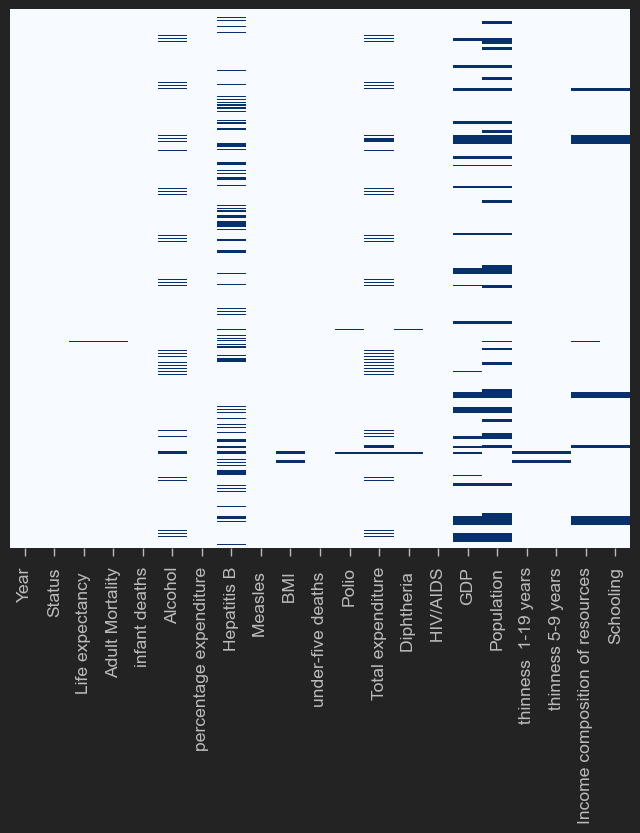

In [31]:
# check if there are any Null values
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap="Blues")
plt.show()

In [33]:
# The first step in analyzing the data is to deal with null values, if we have any, let's visualize where their
# locaiton is. To do that, we use seaborn to plot null values. As a result we have a heatmap that shows blue as
# missing values and white means it has a value. Example, GDP and Population column has a lot of missing values.
# Also, Hepatitis B has a lot of missing values as well. Statues has no missing values, while Life expectancy and
# adult mortality dont have much missing values.

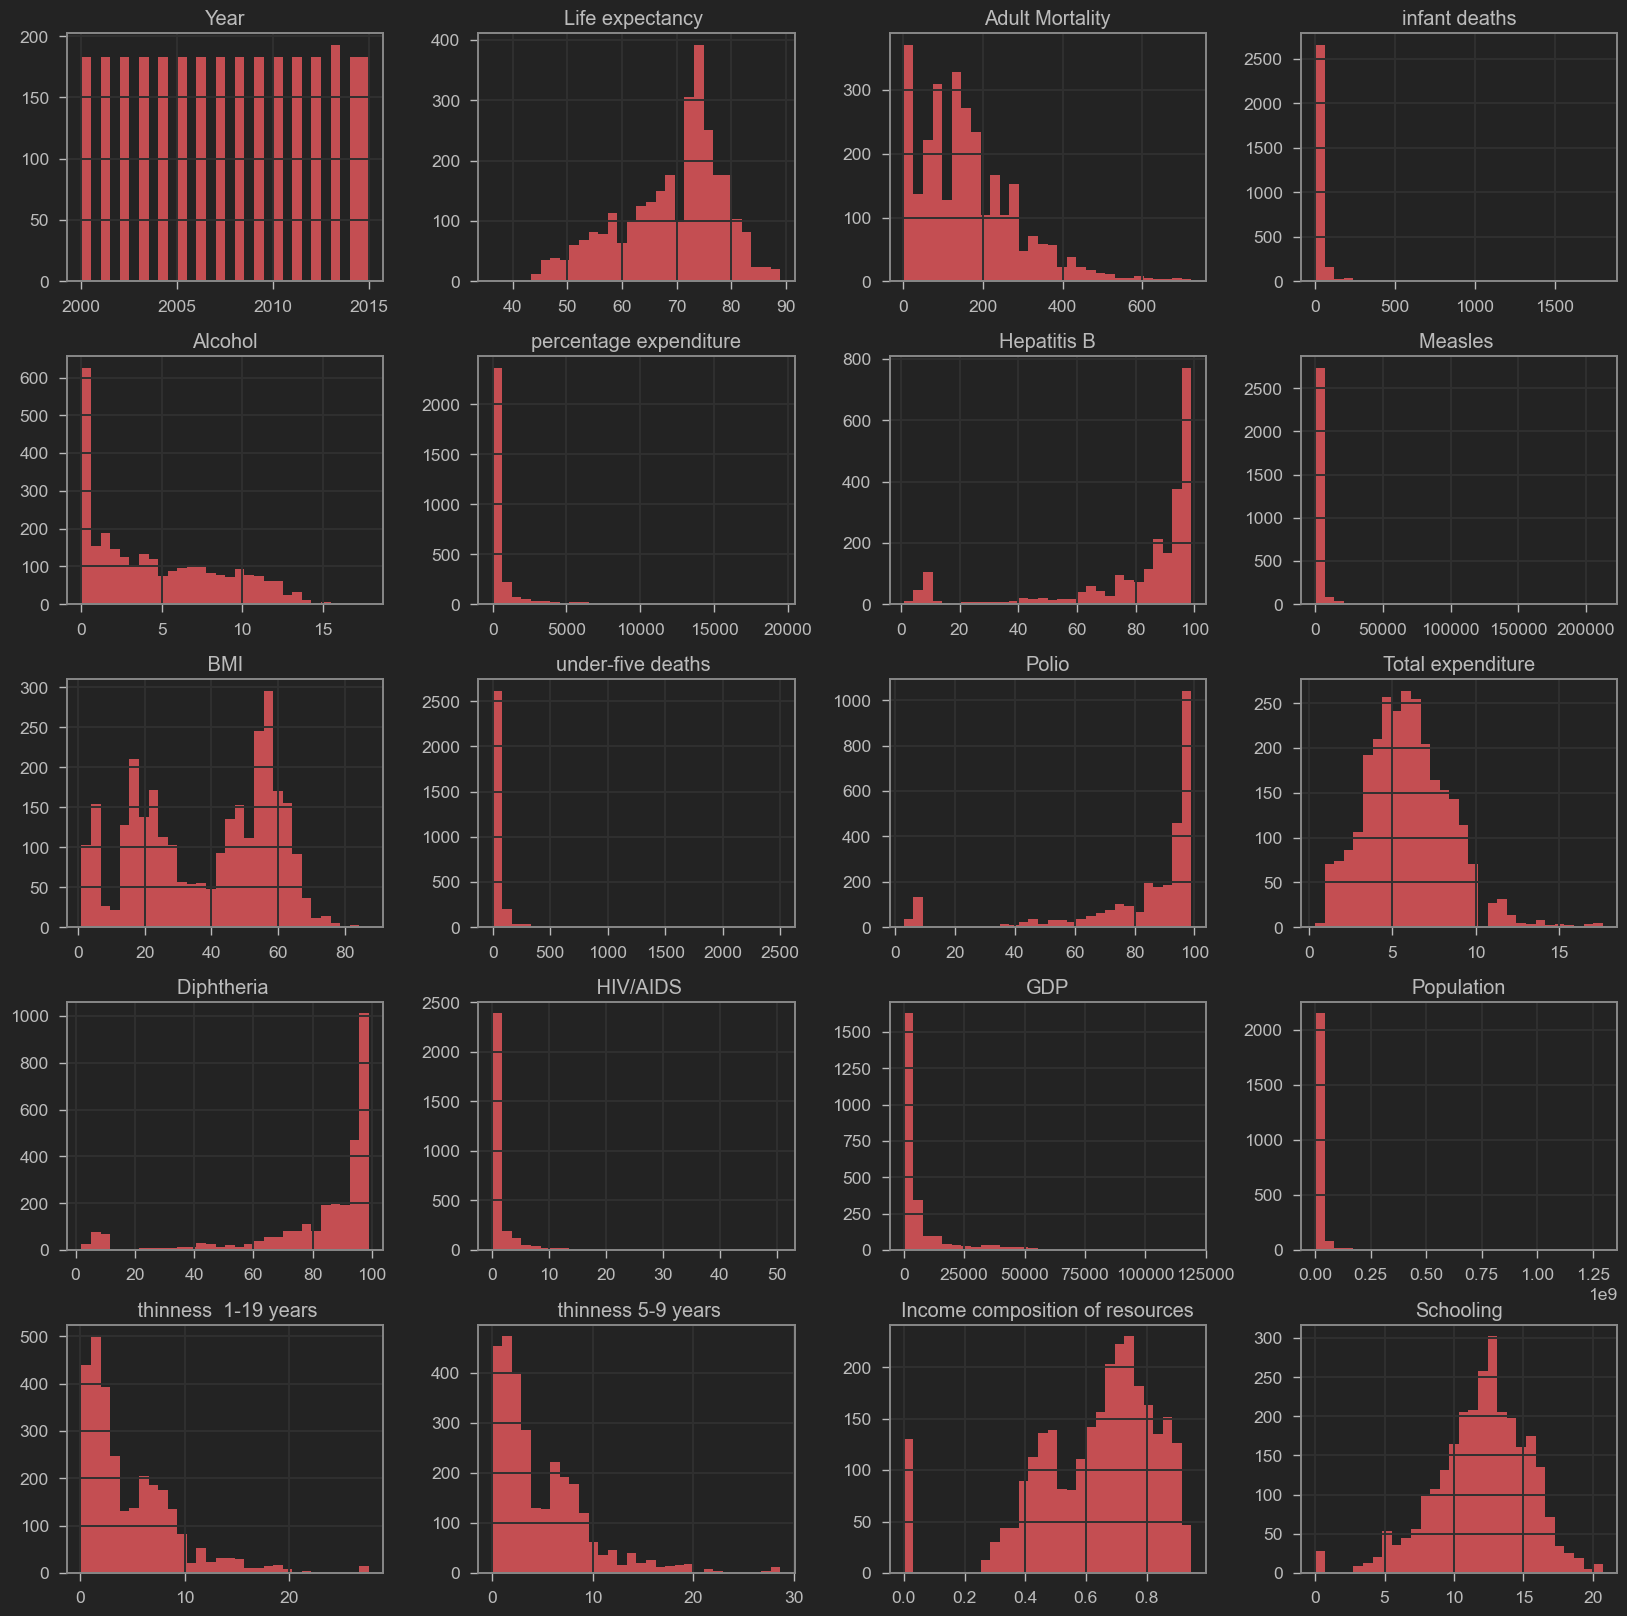

In [35]:
# Plot the histogram
df.hist(bins = 30, figsize = (20, 20), color = 'r');
plt.show()

In [36]:
# What we can see here is that different histogram or distributions for every single column that we have in our 
# data. For example, if you look for life expectancy data, we can see that we dont have a lot of data below 35
# years old and above 90 years old. And that was the minimum and maximum bound that we have in our statistical
# summary if you want to see it above. We can also see that a lot of people or population considered in our study
# are actually between 70 and 80 years. You can also see all the different distributions for the alcohol intake, and
# adult mortality, also for total expenditure.

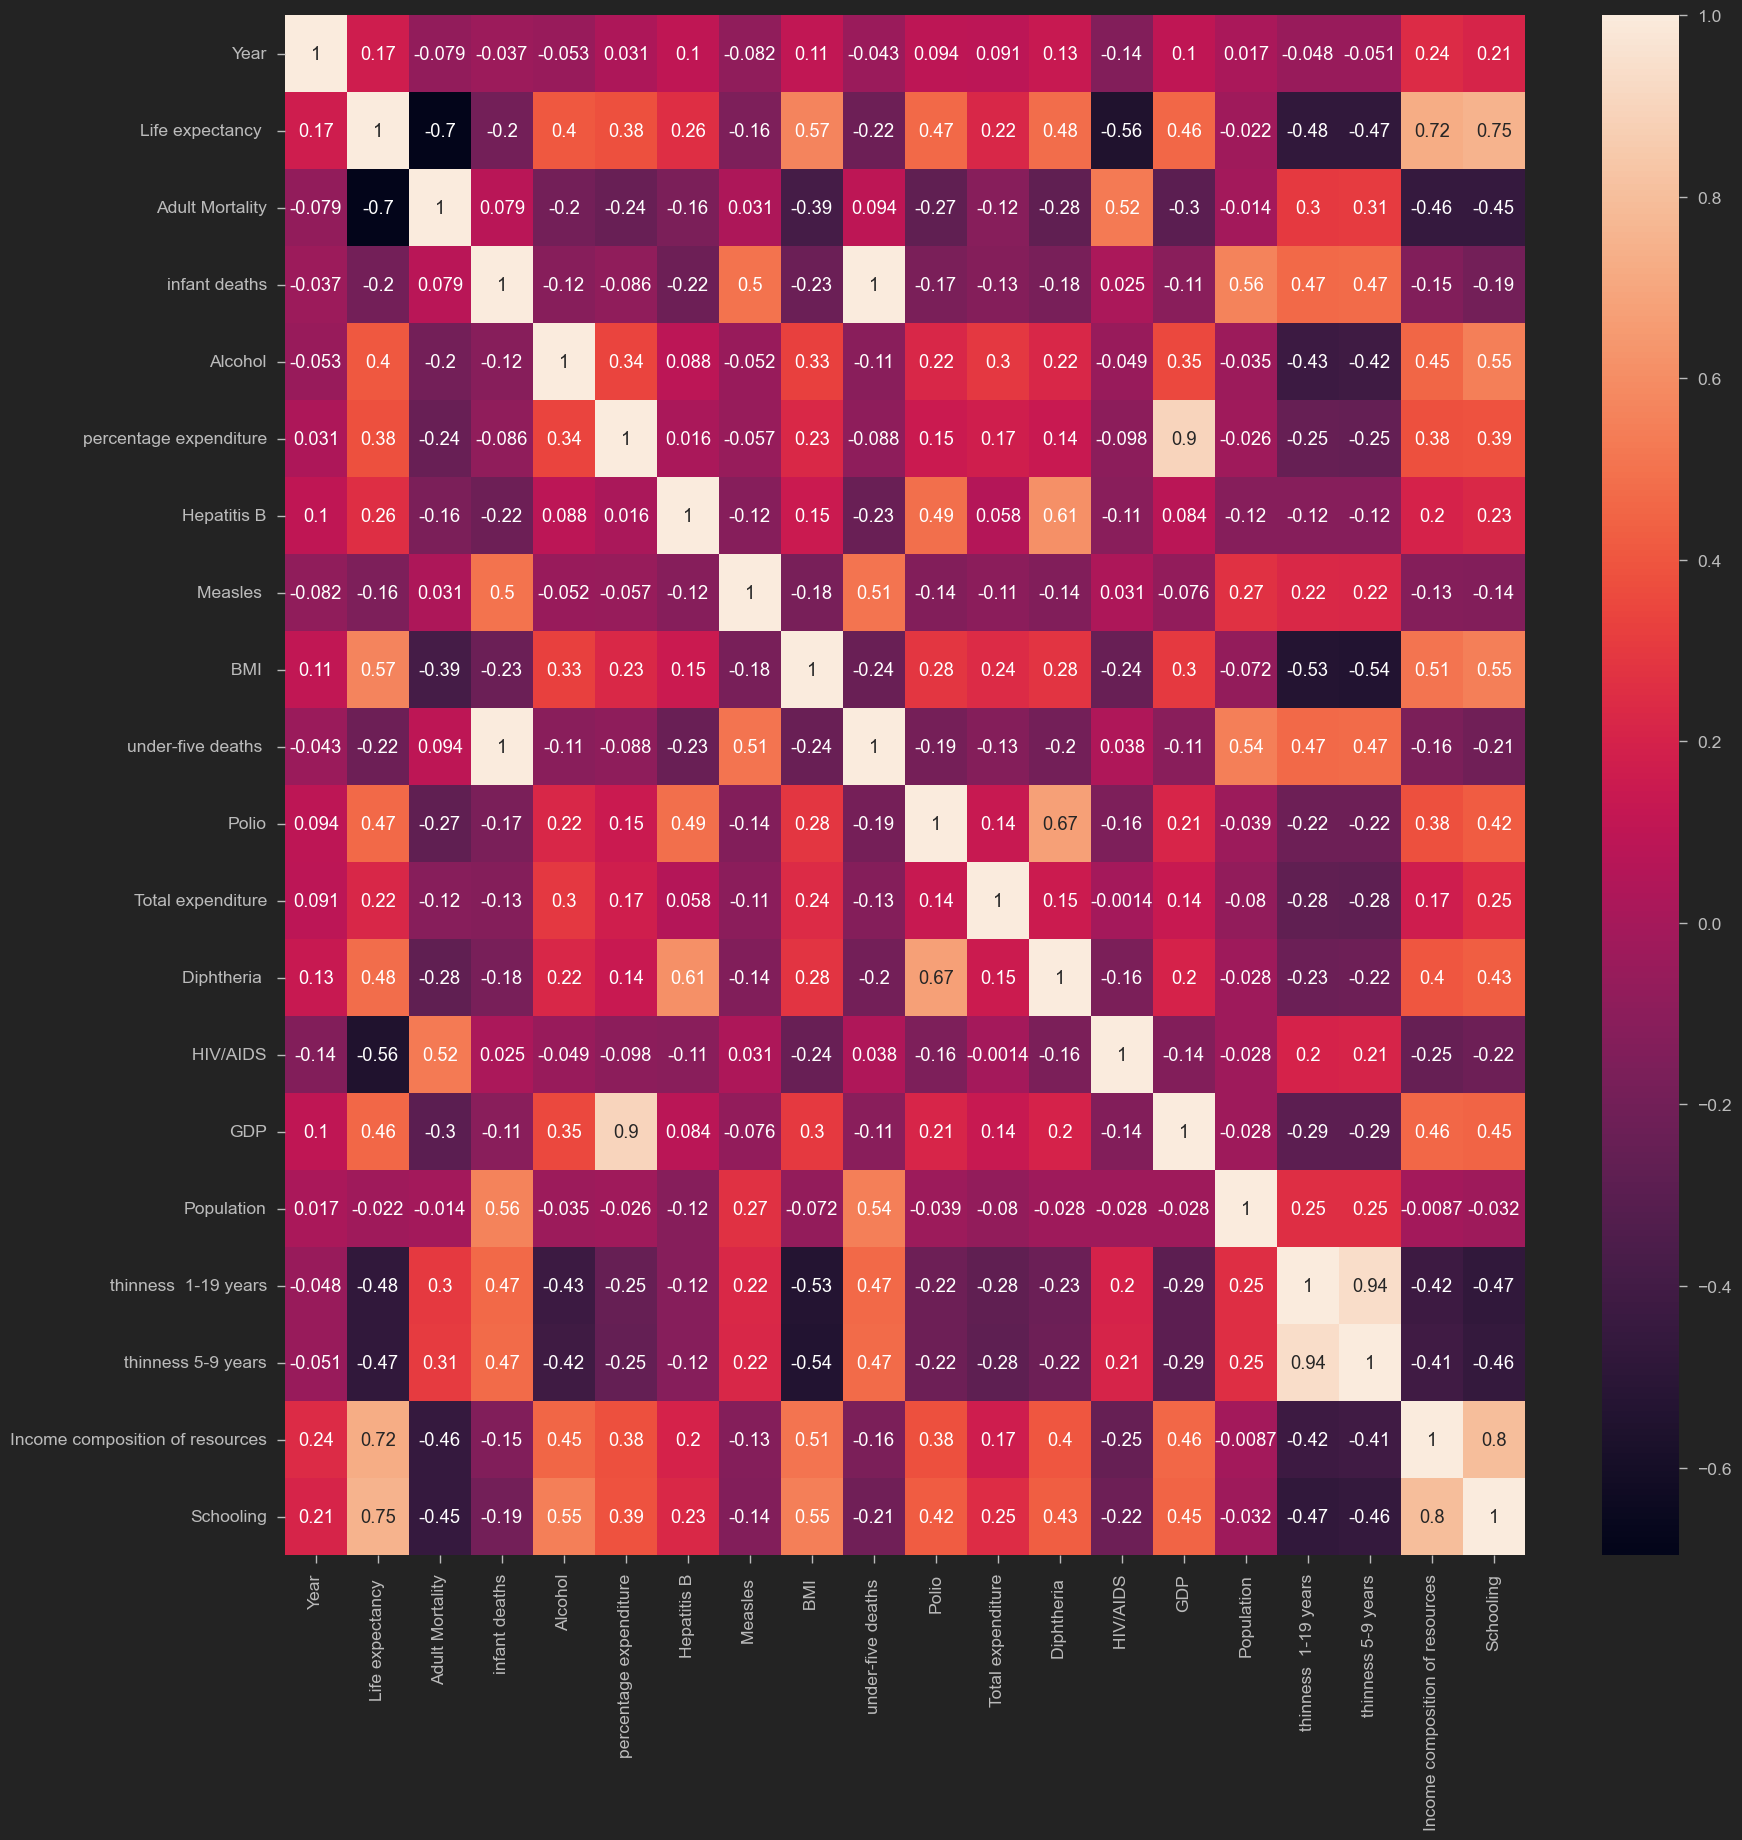

In [37]:
# Plot the correlation matrix (let's remove the developing column since it is an object type and we cant get the
# correlation of that)
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize = (20,20))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot = True)
plt.show()

In [38]:
# What we can see is just by looking at the colors, you can see the any color that is white color indicates that
# there is a strong positive correlation close to 1, and we have any cell that has dark color, that means we are
# talking about negative or inverse correlation between features as you get close to minus 1 and zero indicates we
# dont have any correlation between features. The first point is in the diagonal element here have 1 correlation
# and its the relationship of the feature to itself. We can also see that GDP and Life expectancy has 0.46
# correlation. Its a moderate relationship and it tells us that as GDP increases which is the sum of all the goods
# and services that the country can produce in one year obviously, it will be true that Life expectancy will also
# tend to increase. We can also see that there is this negative correlation here of -0.7. So there is an inverse
# correlation between life expectancy and adult mortality as well, which make sense.

# TASK #4: PERFORM FEATURE ENGINEERING

In [40]:
# Now, what we need to do is to handle missing values first, then i wanted to split the data into inputs and
# outputs. As you will remember, i said before that we will use all the features as an input to our model and only
# the life expectancy column is gonna used as the output of our model. Then, next is to split the data into training
# and testing, 80% and 20% respectively, where we train our model to 80% of the data, the training data, and
# evaluate its performance to the 20% remaining which the model has never seen before, the testing data. 

In [41]:
# Perform one-hot encoding
df = pd.get_dummies(df, columns = ['Status'])

In [42]:
df

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developed,Status_Developing
0,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,...,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,False,True
1,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,...,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,False,True
2,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,...,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,False,True
3,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,...,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,False,True
4,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,...,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,...,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,False,True
2934,2003,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,...,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,False,True
2935,2002,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,...,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,False,True
2936,2001,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,...,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,False,True


In [43]:
# Scrolling to the right we will see that the status column are now one hot encoded.

In [44]:
# Check the number of null values
df.isnull().sum()

Year                                 0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
Status_Developed                     0
Status_Developing                    0
dtype: int64

In [47]:
# Checking missing values and summing them up we have, example, life expectancy has 10 missing values. Also,
# Hepatitis B column has a lot of missing values which is 553 in total. Total expenditures has 226 missing values.
# GDP or gross domestic products has 448 missing data. The population has 652 and so on. Given this missing values,
# we cant just take this data in this form and use to train a machine learning model with it. We first need to
# handle those missing values. One way of handling these messy missing values is simply by deleting it or by
# removing it. The problem with that kind of brute force approach is we are gonna miss a lot of data. We're gonna
# kind of discard a lot of valuable or useful dataset. So alternatively, what we could do is we can calculate the
# average value for each of the columns. And then fill in the average values for all these missing values in the
# data. So, lets specificially get the columns with null values then apply and fill the average to the missing
# values of those columns.

In [48]:
# Check the number of null values for the columns having null values
df.isnull().sum()[np.where(df.isnull().sum() != 0)[0]]

C:\Users\gianc\AppData\Local\Temp\ipykernel_33468\1349342093.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.isnull().sum()[np.where(df.isnull().sum() != 0)[0]]


Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
 BMI                                34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [49]:
# What im gonna do next is to use lambda function to fill in missing values with the mean.

In [50]:
# Since most of the are continous values we fill them with mean
df = df.apply(lambda x: x.fillna(x.mean()),axis=0)

In [55]:
# Running the same code above where we specifically get the columns with null values, it will return none. Since all
# of our column's missing values have been filled in.
df.isnull().sum()[np.where(df.isnull().sum() != 0)[0]]

C:\Users\gianc\AppData\Local\Temp\ipykernel_33468\3001570228.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.isnull().sum()[np.where(df.isnull().sum() != 0)[0]]


Series([], dtype: int64)

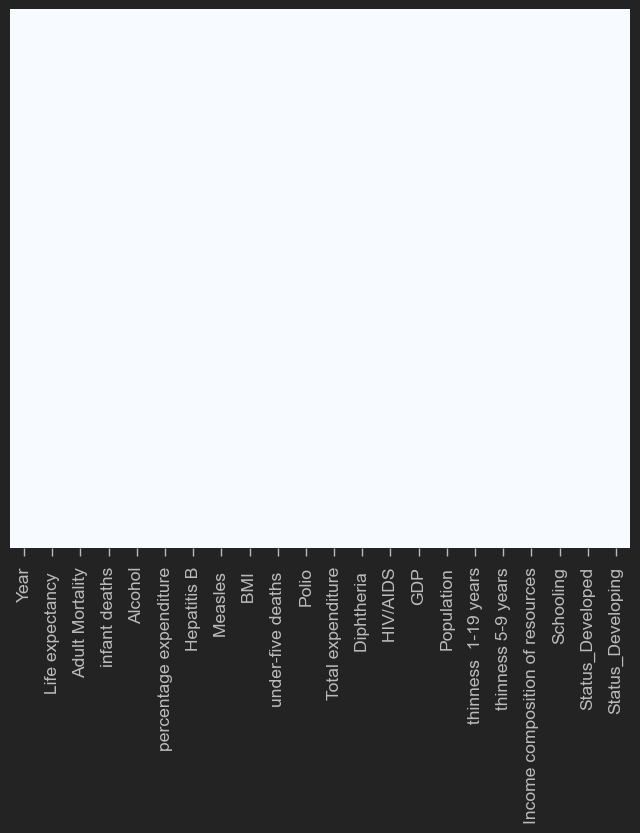

In [64]:
# check if there are any Null values

# Same is true with this vizz. No blue lines since missing values have already been filled in.
# All white meaning we have been able to treat our missing values
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap="Blues")
plt.show()

In [65]:
# Create inputs and outputs data
X = df.drop(columns = ['Life expectancy '])
y = df[['Life expectancy ']]


In [68]:
# Convert the data type to float32
X = np.array(X).astype('float32')
y = np.array(y).astype('float32')

In [70]:
# spliting the data into training 70% and testing 30%
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [72]:
X_train.shape

(2056, 21)

In [74]:
X_test.shape

(882, 21)

# TASK #5: UNDERSTAND XG-BOOST ALGORITHM

In [77]:
# Let's understand XG-Boost algorithm. XG-Boost repeatedly builds new models and combine them into an ensemble
# model. Think of it this way, with XG-Boost algorithm we try to learn from our previous mistakes. Here, we
# initially build the first model, we train a machine learning model first and because this is our first model,
# theres gonna be an error. So the model predictions were not gonna match what we got from the ground truth data.
# So what we gonna do is we calculate the error or residuals of each observation in the dataset. The error is the
# difference between model predictions and the training data. Once the residuals are calculated, we will try to
# learn from our mistakes, we then build a new model to predict those residals (erros). Its like saying, "Im gonna
# go back and try to predict the errors of the mistakes that ive done in my previous model." Then we add that last
# model to the ensemble and then keep repeating over and over. It's like training multiple models and all of these
# models are learning from the mistakes that weve got in the past and were going to scale the output coming out from
# all the models. And thats the concepts of boosting in general. So, overtime the model becomes better and learns
# from its mistakes. XG-Boost offers a lot of superior features compared to gradient boosting algorithm since it
# offers a good balance between bias and variance and it also has a lot of hyper parameters. It has like 40+ hyper
# parameters that you can use to ensure that our model generalize and not memorize on the training data set.
# (Gradient boosting only optimized for the variance so tend to overfit training data while XG-Boost offers
# regularization terms that can improve model generalization).

# TASK #6: TRAIN AN XG-BOOST REGRESSION MODEL 

In [80]:
!pip install xgboost

In [81]:
# Now let's import xgboost as xgb, then use xgb.XGBRegressor then specify the objective function. So the objective
# function here is the squared error. Setting the learning rate to 0.1. Also note that these are the hyper
# parameters, so go ahead and play around with these hyper parameters it will either dramatically improve or worsen
# our model, but we can do some hyper parameter tuning or tweaking so you can get that model then run an optimizer
# and make guesses for all possible different hyper parameters to optimize model performance. Then, im gonna set the
# max depth of the tree to 30. If you can remember when we use XG-Boost were like building multiple trees and that
# will be the depth of the tree. Also the number of estimators is set to 100, basically it tells us how many models,
# how many estimators were gonna have. Then just grab the model and apply the fit method on it, passing X_train and
# y_train.

In [82]:
# Train an XGBoost regressor model 
import xgboost as xgb
model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 30, n_estimators = 100)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=30,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

# TASK #7: ASSESS TRAINED XG-BOOST MODEL PERFORMANCE

In [84]:
# predict the score of the trained model using the testing dataset
result = model.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.9563602805137634


In [85]:
# We got an accuracy of around 96% which is pretty great given that we trained an XG-Boost model in less than a
# minute.

In [86]:
# make predictions on the test data
y_predict = model.predict(X_test)
y_predict

array([74.72837 , 64.64752 , 72.335   , 60.302654, 74.437454, 49.678547,
       77.61336 , 68.72863 , 71.42179 , 77.68518 , 67.56765 , 74.49868 ,
       61.774734, 77.63032 , 75.11595 , 67.12022 , 74.53164 , 64.69438 ,
       66.54667 , 53.544704, 73.64489 , 68.4211  , 68.52459 , 46.418385,
       62.217392, 79.20862 , 58.032658, 61.475407, 82.082306, 65.38153 ,
       73.47713 , 58.157734, 73.580505, 51.776237, 53.540344, 73.70256 ,
       71.97202 , 76.607704, 81.168495, 75.866196, 71.50677 , 67.25467 ,
       81.61383 , 67.484024, 71.23531 , 69.19381 , 57.25725 , 70.17913 ,
       72.36578 , 64.22949 , 62.477768, 58.188118, 73.21004 , 69.06426 ,
       66.925896, 73.37772 , 74.23459 , 79.82003 , 76.86797 , 71.40234 ,
       81.96756 , 58.133766, 73.72895 , 57.81336 , 74.629486, 45.34562 ,
       66.82432 , 69.74469 , 56.27518 , 79.56205 , 80.57543 , 76.80455 ,
       50.13756 , 72.93695 , 72.79674 , 74.99742 , 79.75514 , 72.250916,
       72.96196 , 71.240906, 76.181305, 71.08231 , 

In [87]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
k = X_test.shape[1]
n = len(X_test)
RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)),'.3f'))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
adj_r2 = 1-(1-r2)*(n-1)/(n-k-1)

print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2, '\nAdjusted R2 =', adj_r2) 

RMSE = 1.958 
MSE = 3.83287 
MAE = 1.195024 
R2 = 0.9563602805137634 
Adjusted R2 = 0.9552946594565414


### Set the max depth hyperparameter to a very small number and retrain the model
### What do we infer from these results?

In [89]:
# Train an XGBoost regressor model
import xgboost as xgb
model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 2, n_estimators = 100)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [90]:
# predict the score of the trained model using the testing dataset
result = model.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.9183793663978577


In [91]:
# make predictions on the test data
y_predict = model.predict(X_test)
y_predict

array([74.702225, 64.111244, 71.83721 , 62.810272, 73.57476 , 51.069695,
       75.51362 , 68.08944 , 73.14634 , 75.92842 , 69.33139 , 73.0728  ,
       60.941677, 77.44137 , 75.06633 , 69.36238 , 75.0448  , 67.39858 ,
       69.29225 , 55.507763, 72.07776 , 69.50201 , 69.24769 , 46.509014,
       61.453426, 79.86332 , 55.927948, 60.899776, 83.62986 , 65.43803 ,
       73.34464 , 58.32459 , 72.924385, 51.804752, 53.31031 , 74.169876,
       71.66651 , 78.31068 , 81.12053 , 76.81241 , 69.50173 , 69.67751 ,
       80.44288 , 68.92581 , 70.47889 , 70.68335 , 56.735447, 71.685745,
       74.604004, 66.11271 , 62.72547 , 57.370785, 74.10837 , 69.62483 ,
       69.116875, 72.92727 , 74.95361 , 82.025055, 76.08565 , 71.68576 ,
       82.1195  , 57.021084, 75.13959 , 57.40222 , 72.69324 , 44.302776,
       66.267105, 67.9961  , 54.069065, 79.49912 , 78.83837 , 74.37742 ,
       50.773632, 73.74737 , 69.100815, 74.79747 , 78.50623 , 66.914665,
       73.19631 , 70.76624 , 72.978035, 72.360146, 

In [92]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
k = X_test.shape[1]
n = len(X_test)
RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)),'.3f'))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
adj_r2 = 1-(1-r2)*(n-1)/(n-k-1)

print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2, '\nAdjusted R2 =', adj_r2) 

RMSE = 2.677 
MSE = 7.1687284 
MAE = 1.893258 
R2 = 0.9183793663978577 
Adjusted R2 = 0.9163863044145495


In [93]:
# Train an XGBoost regressor model
import xgboost as xgb
model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 8, n_estimators = 100)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [94]:
# predict the score of the trained model using the testing dataset
result = model.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.9584201574325562


In [95]:
# make predictions on the test data
y_predict = model.predict(X_test)
y_predict

array([75.035   , 63.813286, 72.09247 , 58.6989  , 74.183426, 49.203545,
       77.01861 , 70.44105 , 72.15035 , 78.37969 , 67.01601 , 72.97517 ,
       61.77781 , 77.75342 , 75.1461  , 66.47766 , 74.4919  , 64.66638 ,
       67.2326  , 52.071835, 74.79683 , 68.27697 , 69.18152 , 46.18195 ,
       62.225952, 79.247894, 58.109936, 61.428047, 82.542564, 65.533066,
       73.45402 , 57.461884, 72.80343 , 52.77899 , 53.83048 , 74.17765 ,
       71.990776, 76.98545 , 81.82716 , 76.29923 , 71.142235, 66.50317 ,
       82.26431 , 67.85113 , 70.45027 , 69.61447 , 56.846294, 70.23424 ,
       73.22408 , 63.761665, 62.191494, 58.232204, 73.451645, 68.93857 ,
       66.96037 , 73.0225  , 74.21576 , 81.19944 , 76.734436, 70.220085,
       81.07869 , 57.54806 , 74.15361 , 57.48817 , 75.27583 , 44.110382,
       67.1967  , 70.06444 , 55.318455, 79.93247 , 79.23088 , 75.17106 ,
       49.334324, 73.55369 , 72.38546 , 74.79227 , 79.61479 , 72.10567 ,
       72.48706 , 72.1184  , 75.49052 , 71.21368 , 

In [98]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
k = X_test.shape[1]
n = len(X_test)
RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)),'.3f'))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
adj_r2 = 1-(1-r2)*(n-1)/(n-k-1)

print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2, '\nAdjusted R2 =', adj_r2) 

RMSE = 1.911 
MSE = 3.6519496 
MAE = 1.1977254 
R2 = 0.9584201574325562 
Adjusted R2 = 0.9574048356954441


In [99]:
# An XG-Boost regression model was trained and evaluated using different values of max_depth to understand how
# model complexity affects predictive performance. The model was assessed using R2, Adjusted R2, RMSE, MSE, and MAE,
# which collectively measure goodness of fit and prediction error.

# The baseline model has a max_depth of 30. The model explains approximately 95.63% of the variane in the target
# variable, indicating string predictive power. However, a 30 max_depth allows very deep trees, which can capture
# complex patterns but also increases the risk of overfitting, especially if the dataset is not extremely large. The
# small gap between R2 and Adjusted R2 suggests that overfitting is controlled but still possible given the high
# model complexity.

# We retrain the model using max_depth of 2. With a shallow tree depth, the model's performance drops significantly
# to 91.83%. The higher RMSE and MAE indicate larger prediction errors, and the reduced R2 suggests underfitting.
# This configuration is too simple to capture the underlying relationships in the data, leading to loss of important
# nonlinear interactions.

# Last, we retrain but this time using max_depth of 8. Which as we can see is the best of the 3 models. This model
# achieves the best overall performance. It explains 95.84 of the variance, with the lowest prediction error across
# RMSE and MAE. The close alignment between R2 and Adjusted R2 indicates that the model generalizes well and is not
# relying on unnecessary complexity.

# The XGBoost regressor with max_depth of 8 is the optimal model, delivering the best predictive accuracy and
# generalization. It captures nonlinear relationships effectively without unnecessary complexity

In [100]:
# RECOMMENDATION:

# 1. Apply cross-validation (xgb.cv or GridSearchCV)
# 2. Tune additional hyperparameters:
    # min_child_weight
    # subsample
    # colsample_bytree
    # gamma
# 3. Examine feature importance to improve interpretability

# EXCELLENT JOB!